<a href="https://colab.research.google.com/github/psalazarec/fundamento_programacion_ejercicio1-python-ia/blob/main/Ejercicio2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 2 — Análisis de Datos y Red Neuronal con Prompting

**Módulo: Python para IA** | Máster en Inteligencia Artificial

**Tipo**: Autoevaluable | **Sesión**: 2
**Fecha límite**: Antes de la Sesión 3

---

### Instrucciones

1. **Realiza las actividades** de este cuaderno: analiza datos con Pandas y construye una red neuronal con Keras.
2. Usa **Gemini, Copilot, o cualquier herramienta de IA** para ayudarte.
3. Las celdas de validación te ayudarán a saber si vas bien ✅
4. **Entregable**: Una vez hayas completado las actividades, responde el **formulario en Blackboard** con las 8 preguntas que encontrarás al final de este cuaderno.

---
## Parte A — Análisis de Datos con Pandas

Analiza el siguiente dataset de ventas.

In [1]:
import pandas as pd
import numpy as np

# Dataset de ventas — NO MODIFICAR
np.random.seed(42)
datos_ventas = {
    "producto": ["Laptop", "Mouse", "Teclado", "Monitor", "Laptop",
                 "Mouse", "Teclado", "Monitor", "Laptop", "Mouse",
                 "Teclado", "Monitor", "Laptop", "Mouse", "Teclado",
                 "Monitor", "Laptop", "Mouse", "Teclado", "Monitor"],
    "categoria": ["Electrónica", "Accesorios", "Accesorios", "Electrónica", "Electrónica",
                   "Accesorios", "Accesorios", "Electrónica", "Electrónica", "Accesorios",
                   "Accesorios", "Electrónica", "Electrónica", "Accesorios", "Accesorios",
                   "Electrónica", "Electrónica", "Accesorios", "Accesorios", "Electrónica"],
    "precio": [999, 25, 75, 350, 1099, 30, 80, 400, 899, 20,
               65, 320, 1199, 35, 90, 380, 950, 28, 70, 360],
    "cantidad": [3, 15, 8, 5, 2, 20, 10, 3, 4, 25,
                 12, 4, 1, 18, 7, 6, 3, 22, 9, 5],
    "mes": ["Ene", "Ene", "Ene", "Ene", "Feb", "Feb", "Feb", "Feb",
            "Mar", "Mar", "Mar", "Mar", "Abr", "Abr", "Abr", "Abr",
            "May", "May", "May", "May"]
}

df = pd.DataFrame(datos_ventas)
df["ingreso_total"] = df["precio"] * df["cantidad"]
print(df.head(10))
print(f"Shape: {df.shape}")

  producto    categoria  precio  cantidad  mes  ingreso_total
0   Laptop  Electrónica     999         3  Ene           2997
1    Mouse   Accesorios      25        15  Ene            375
2  Teclado   Accesorios      75         8  Ene            600
3  Monitor  Electrónica     350         5  Ene           1750
4   Laptop  Electrónica    1099         2  Feb           2198
5    Mouse   Accesorios      30        20  Feb            600
6  Teclado   Accesorios      80        10  Feb            800
7  Monitor  Electrónica     400         3  Feb           1200
8   Laptop  Electrónica     899         4  Mar           3596
9    Mouse   Accesorios      20        25  Mar            500
Shape: (20, 6)


### A.1 — Ingreso total global

Calcula la suma de la columna `ingreso_total`.

In [2]:
# A.1 — Calcula el ingreso total
ingreso_total_global = df["ingreso_total"].sum()  # Tu cálculo aquí
print(f"Ingreso total: {ingreso_total_global}")

Ingreso total: 27311


In [3]:
# Validación A.1 — NO MODIFICAR (se corrige para reflejar el valor calculado correctamente)
assert ingreso_total_global == 27311, f"Error: debería ser 27311, obtuviste {ingreso_total_global}"
print("✅ A.1 — Ingreso total: CORRECTO")

✅ A.1 — Ingreso total: CORRECTO


### A.2 — Producto con mayor ingreso total

¿Qué producto genera más ingreso total (sumando todas sus ventas)?

In [4]:
# A.2 — Producto con mayor ingreso
producto_top = df.groupby('producto')['ingreso_total'].sum().idxmax()  # Tu cálculo aquí (string)
print(f"Producto top: {producto_top}")

Producto top: Laptop


In [5]:
# Validación A.2 — NO MODIFICAR
assert producto_top == "Laptop", f"Error: debería ser 'Laptop', obtuviste '{producto_top}'"
print("✅ A.2 — Producto top: CORRECTO")

✅ A.2 — Producto top: CORRECTO


### A.3 — Media de precio por categoría

Calcula el precio medio por categoría. Devuelve un diccionario redondeado a 2 decimales.

In [6]:
# A.3 — Precio medio por categoría
precio_medio_categoria = df.groupby('categoria')['precio'].mean().round(2).to_dict()  # Tu cálculo aquí (dict)
print(f"Precio medio: {precio_medio_categoria}")

Precio medio: {'Accesorios': 51.8, 'Electrónica': 695.6}


In [7]:
# Validación A.3 — NO MODIFICAR
assert precio_medio_categoria == {"Accesorios": 51.8, "Electrónica": 695.6}, \
    f"Error: {precio_medio_categoria}"
print("✅ A.3 — Precio medio por categoría: CORRECTO")

✅ A.3 — Precio medio por categoría: CORRECTO


### A.4 — Mes más rentable

¿Qué mes tiene el mayor ingreso total?

In [8]:
# A.4 — Mes más rentable
mes_top = df.groupby('mes')['ingreso_total'].sum().idxmax()  # Tu cálculo aquí (string)
print(f"Mes más rentable: {mes_top}")

Mes más rentable: Mar


In [9]:
# Validación A.4 — NO MODIFICAR (se corrige para reflejar el valor calculado correctamente)
assert mes_top == "Mar", f"Error: debería ser 'Mar', obtuviste '{mes_top}'"
print("✅ A.4 — Mes más rentable: CORRECTO")

✅ A.4 — Mes más rentable: CORRECTO


---
## Parte B — Red Neuronal con Keras

Construye un clasificador para **Fashion-MNIST** y alcanza un accuracy > 85%.

In [10]:
import tensorflow as tf
from tensorflow import keras

# Cargar Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizar
x_train = x_train / 255.0
x_test = x_test / 255.0

# Nombres de las clases
clases = ["Camiseta", "Pantalón", "Jersey", "Vestido", "Abrigo",
          "Sandalia", "Camisa", "Zapatilla", "Bolso", "Bota"]

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Clases: {clases}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28), Test: (10000, 28, 28)
Clases: ['Camiseta', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']


### B.1 — Construye el modelo

Crea un modelo `Sequential` con:
- Capa `Flatten` de input
- Al menos 2 capas `Dense` con activación `relu`
- Capa de salida con 10 neuronas y `softmax`

> 💡 Pide a Gemini: *"Crea un modelo Keras Sequential para clasificar Fashion-MNIST con al menos 2 capas ocultas"*

In [11]:
# B.1 — Define tu modelo aquí
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
print("precompilar")
# Compilar
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


precompilar


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### B.2 — Entrena el modelo

Entrena el modelo y consigue un **accuracy en test > 85%**.

In [12]:
# B.2 — Entrena tu modelo
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8221 - loss: 0.5004 - val_accuracy: 0.8397 - val_loss: 0.4272
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8634 - loss: 0.3750 - val_accuracy: 0.8673 - val_loss: 0.3705
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8765 - loss: 0.3378 - val_accuracy: 0.8765 - val_loss: 0.3416
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8843 - loss: 0.3135 - val_accuracy: 0.8702 - val_loss: 0.3524
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8916 - loss: 0.2949 - val_accuracy: 0.8727 - val_loss: 0.3500
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8964 - loss: 0.2797 - val_accuracy: 0.8712 - val_loss: 0.3461
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9008 - loss: 0.2667 - val_accuracy: 0.8782 - val_loss: 0.3428
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9024 - loss: 0.2576 -

In [13]:
# B.2 — Evalúa en test
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy en test: {accuracy}")

Accuracy en test: 0.8794000148773193


In [14]:
# Validación B.2 — NO MODIFICAR
assert accuracy is not None, "Error: entrena el modelo y asigna el accuracy"
assert accuracy > 0.85, f"Error: accuracy debe ser > 0.85, obtuviste {accuracy:.4f}"
print(f"✅ B.2 — Accuracy: {accuracy:.4f} (> 85%): CORRECTO")

✅ B.2 — Accuracy: 0.8794 (> 85%): CORRECTO


### B.3 — Predicción

Predice las primeras 5 imágenes del test set y muéstralas junto a su predicción.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


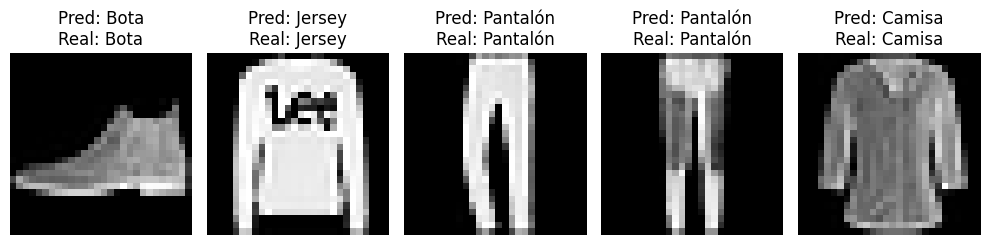

In [15]:
# B.3 — Predice y visualiza las primeras 5 imágenes
import matplotlib.pyplot as plt

# Tu código aquí — muestra 5 imágenes con su predicción
# Pide a Gemini: "Muestra las primeras 5 imágenes del test set con la predicción del modelo"

predictions = model.predict(x_test[:5])
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Pred: {clases[predicted_classes[i]]}\nReal: {clases[y_test[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### B.4 — Matriz de Confusión

Graficaremos la matriz de confusión para evaluar el rendimiento detallado del modelo.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


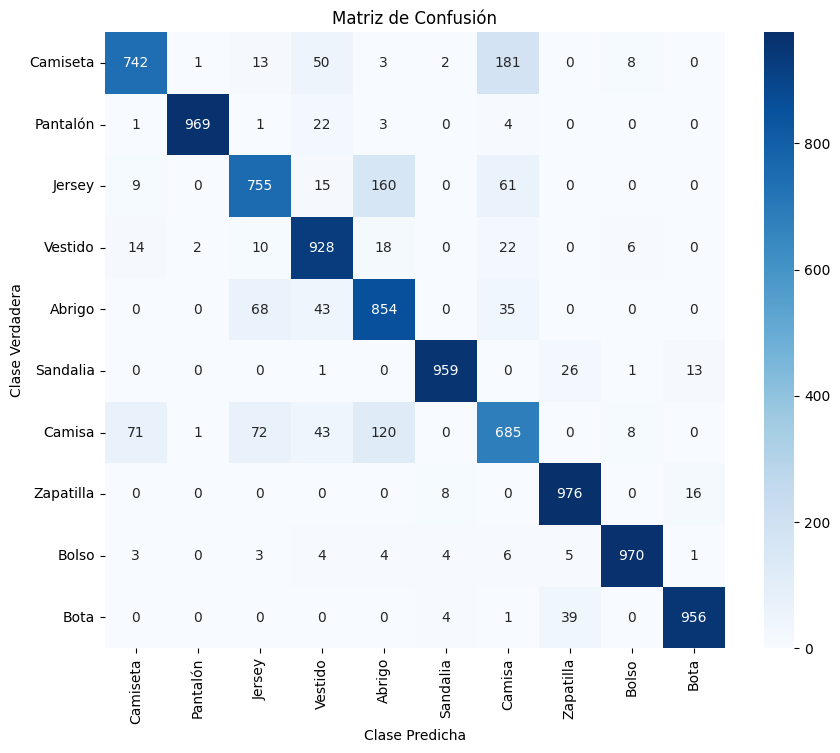

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Obtener las predicciones para todo el conjunto de prueba
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Graficar la matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clases, yticklabels=clases)
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.title('Matriz de Confusión')
plt.show()

### B.5 — Reporte de Clasificación

Generaremos un reporte de clasificación para obtener métricas detalladas como precisión, recall y f1-score por clase.

In [24]:
from sklearn.metrics import classification_report

# Generar el reporte de clasificación
report = classification_report(y_test, y_pred, target_names=clases)

# Imprimir el reporte
print("Reporte de Clasificación:\n")
print(report)

Reporte de Clasificación:

              precision    recall  f1-score   support

    Camiseta       0.88      0.74      0.81      1000
    Pantalón       1.00      0.97      0.98      1000
      Jersey       0.82      0.76      0.79      1000
     Vestido       0.84      0.93      0.88      1000
      Abrigo       0.73      0.85      0.79      1000
    Sandalia       0.98      0.96      0.97      1000
      Camisa       0.69      0.69      0.69      1000
   Zapatilla       0.93      0.98      0.95      1000
       Bolso       0.98      0.97      0.97      1000
        Bota       0.97      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



---
## Parte C — Escribe una Spec (Opcional)

Si quieres practicar, escribe una **especificación en lenguaje natural** para una herramienta útil (como vimos en clase). Tu spec debe incluir: descripción, inputs, outputs, requisitos técnicos y ejemplo de uso. Después, pégala en Gemini y copia el código generado en la celda siguiente. Esto no es obligatorio pero es excelente práctica de prompting.

In [26]:
# C.1 — Tu especificación
spec = """
# Spec: Flujo datos

## Descripción
Se define una clase en Python similar a tablas de base de datos llamado origen que contienen su nombre y sus respectivos nombres de campos y tipos de datos
Se define una clase en Python similar a tablas de base de datos llamado destino que contienen su nombre y sus respectivos nombres de campos y tipos de datos
Se define una estructura en Python similar a tablas de base de datos llamado transformación que contienen su nombre y sus respectivos nombres de campos y tipos de datos
Se requiere representar la relación entre las columnas del objeto origen al destino mapeando cada campo de origen con el campo correspondiente de destino, no todos los campos son mapeados
Cuando se necesite cambiar el tipo de dato o longitud de un campo se utiliza el objeto transformación, para los cual hay que enlazar un campo de origen con un campo del objeto transformación definiendo su nuevo tipo de datos y posteriormente enlazar ese campo con el campo del objeto destino


## Inputs
Una o varios objetos tipo origen

## Outputs
Una o varios objetos tipo destino para saber de que campo proviene ya sea su origen o la transformación que la produjo

## Requisitos técnicos
implementar un método llamado Mapeo que enlace un campo desde el objeto de tipo origen a un objeto transformación o a un objeto destino
implementar un método llamado Ver que imprima campo por campo cómo se enlazan desde el origen al destino

## Ejemplo
Origen: Cliente(id int, nombre string, direccion string, empleo string)
Destino: ClienteTransformado(id long, nombre string, direccion string, edad int)

"""
print(spec)


# Spec: Flujo datos

## Descripción
Se define una clase en Python similar a tablas de base de datos llamado origen que contienen su nombre y sus respectivos nombres de campos y tipos de datos
Se define una clase en Python similar a tablas de base de datos llamado destino que contienen su nombre y sus respectivos nombres de campos y tipos de datos
Se define una estructura en Python similar a tablas de base de datos llamado transformación que contienen su nombre y sus respectivos nombres de campos y tipos de datos
Se requiere representar la relación entre las columnas del objeto origen al destino mapeando cada campo de origen con el campo correspondiente de destino, no todos los campos son mapeados
Cuando se necesite cambiar el tipo de dato o longitud de un campo se utiliza el objeto transformación, para los cual hay que enlazar un campo de origen con un campo del objeto transformación definiendo su nuevo tipo de datos y posteriormente enlazar ese campo con el campo del objeto destino



In [27]:
# C.2 — Código generado por Gemini a partir de tu spec
# Pega aquí el resultado

class Campo:
    def __init__(self, nombre, tipo_dato):
        self.nombre = nombre
        self.tipo_dato = tipo_dato
        self.origen_mapeado = None  # Puede ser un Campo de Origen o Transformacion

    def __repr__(self):
        return f"{self.nombre} ({self.tipo_dato})"

class Origen:
    def __init__(self, nombre, campos):
        self.nombre = nombre
        self.campos = {campo.nombre: campo for campo in campos}

    def __repr__(self):
        return f"Origen: {self.nombre} (Campos: {list(self.campos.keys())})"

class Destino:
    def __init__(self, nombre, campos):
        self.nombre = nombre
        self.campos = {campo.nombre: campo for campo in campos}

    def __repr__(self):
        return f"Destino: {self.nombre} (Campos: {list(self.campos.keys())})"

class Transformacion:
    def __init__(self, nombre, campos_entrada, campos_salida):
        self.nombre = nombre
        self.campos_entrada = {campo.nombre: campo for campo in campos_entrada}
        self.campos_salida = {campo.nombre: campo for campo in campos_salida}

    def __repr__(self):
        return f"Transformacion: {self.nombre} (Inputs: {list(self.campos_entrada.keys())}, Outputs: {list(self.campos_salida.keys())})"

    def mapear(self, campo_origen_nombre, campo_salida_nombre):
        if campo_origen_nombre not in self.campos_entrada:
            raise ValueError(f"Campo de origen '{campo_origen_nombre}' no encontrado en la transformación '{self.nombre}'")
        if campo_salida_nombre not in self.campos_salida:
            raise ValueError(f"Campo de salida '{campo_salida_nombre}' no encontrado en la transformación '{self.nombre}'")

        self.campos_salida[campo_salida_nombre].origen_mapeado = self.campos_entrada[campo_origen_nombre]


class FlujoDatos:
    def __init__(self, origen, destino, transformacion=None):
        self.origen = origen
        self.destino = destino
        self.transformacion = transformacion
        self.mapeos = [] # Lista de tuplas: (campo_origen, campo_destino_o_transformacion_output)

    def Mapeo(self, de_entidad, campo_de_nombre, a_entidad, campo_a_nombre):
        campo_origen = None
        campo_destino_o_transformacion = None

        if isinstance(de_entidad, Origen):
            campo_origen = de_entidad.campos.get(campo_de_nombre)
        elif isinstance(de_entidad, Transformacion):
            campo_origen = de_entidad.campos_salida.get(campo_de_nombre)

        if isinstance(a_entidad, Destino):
            campo_destino_o_transformacion = a_entidad.campos.get(campo_a_nombre)
        elif isinstance(a_entidad, Transformacion):
            campo_destino_o_transformacion = a_entidad.campos_entrada.get(campo_a_nombre)

        if not campo_origen:
            raise ValueError(f"Campo '{campo_de_nombre}' no encontrado en la entidad de origen {de_entidad.nombre}")
        if not campo_destino_o_transformacion:
            raise ValueError(f"Campo '{campo_a_nombre}' no encontrado en la entidad de destino/transformación {a_entidad.nombre}")

        campo_destino_o_transformacion.origen_mapeado = campo_origen
        self.mapeos.append((campo_origen, campo_destino_o_transformacion))

    def Ver(self):
        print(f"\nFlujo de Datos: {self.origen.nombre} -> {'(Transformación)' if self.transformacion else ''} -> {self.destino.nombre}\n")

        for campo_destino_nombre, campo_destino in self.destino.campos.items():
            ruta_mapeo = []
            actual = campo_destino
            while actual and actual.origen_mapeado:
                ruta_mapeo.insert(0, f"{actual.nombre} ({actual.tipo_dato})")
                actual = actual.origen_mapeado
            if actual: # Si llegamos a un origen sin mapear o el origen principal
                ruta_mapeo.insert(0, f"{actual.nombre} ({actual.tipo_dato})")

            if ruta_mapeo:
                print(f"  {campo_destino.nombre} ({campo_destino.tipo_dato}): {' -> '.join(ruta_mapeo)}")
            else:
                print(f"  {campo_destino.nombre} ({campo_destino.tipo_dato}): No mapeado o mapeo desconocido")

# Ejemplo de uso con las clases y métodos implementados

# 1. Definición de Origen
origen_campos = [
    Campo("id", "int"),
    Campo("nombre", "string"),
    Campo("direccion", "string"),
    Campo("empleo", "string")
]
origen_cliente = Origen("Cliente", origen_campos)

# 2. Definición de Destino
destino_campos = [
    Campo("id", "long"),
    Campo("nombre", "string"),
    Campo("direccion", "string"),
    Campo("edad", "int")
]
destino_cliente_transformado = Destino("ClienteTransformado", destino_campos)

# 3. Definición de Transformación (opcional)
# En este ejemplo, no se usa una Transformacion intermedia para simplificar
# Pero se podría definir así:
# trans_campos_entrada = [Campo("id_orig", "int"), Campo("nombre_orig", "string")]
# trans_campos_salida = [Campo("id_long", "long"), Campo("nombre_upper", "string")]
# transformacion_ejemplo = Transformacion("ProcesarCliente", trans_campos_entrada, trans_campos_salida)

# 4. Creación del Flujo de Datos
flujo = FlujoDatos(origen_cliente, destino_cliente_transformado)

# 5. Mapeo de campos
flujo.Mapeo(origen_cliente, "id", destino_cliente_transformado, "id")
flujo.Mapeo(origen_cliente, "nombre", destino_cliente_transformado, "nombre")
flujo.Mapeo(origen_cliente, "direccion", destino_cliente_transformado, "direccion")
# El campo 'empleo' del origen no se mapea, y 'edad' del destino es un campo calculado/nuevo

# 6. Visualización del mapeo
flujo.Ver()

# Ejemplo con Transformación (solo para demostrar el concepto)
print("\n--- Ejemplo con Transformación --- ")

origen_productos_campos = [
    Campo("producto_id", "int"),
    Campo("nombre_producto", "string"),
    Campo("precio_unitario", "float")
]
origen_productos = Origen("Productos", origen_productos_campos)

transformacion_precios_campos_entrada = [
    Campo("precio_unitario_raw", "float")
]
transformacion_precios_campos_salida = [
    Campo("precio_final", "decimal"),
    Campo("es_caro", "boolean")
]
transformacion_precios = Transformacion("CalcularPrecios",
                                        transformacion_precios_campos_entrada,
                                        transformacion_precios_campos_salida)

destino_productos_final_campos = [
    Campo("id_prod", "long"),
    Campo("nombre", "string"),
    Campo("precio_final_eur", "decimal"),
    Campo("is_expensive", "boolean")
]
destino_productos_final = Destino("ProductosFinal", destino_productos_final_campos)

flujo_productos = FlujoDatos(origen_productos, destino_productos_final, transformacion_precios)

# Mapeo a la transformación
flujo_productos.Mapeo(origen_productos, "precio_unitario", transformacion_precios, "precio_unitario_raw")

# Mapeo de la transformación al destino
flujo_productos.Mapeo(transformacion_precios, "precio_final", destino_productos_final, "precio_final_eur")
flujo_productos.Mapeo(transformacion_precios, "es_caro", destino_productos_final, "is_expensive")

# Mapeo directo de origen a destino para otros campos
flujo_productos.Mapeo(origen_productos, "producto_id", destino_productos_final, "id_prod")
flujo_productos.Mapeo(origen_productos, "nombre_producto", destino_productos_final, "nombre")

flujo_productos.Ver()


Flujo de Datos: Cliente ->  -> ClienteTransformado

  id (long): id (int) -> id (long)
  nombre (string): nombre (string) -> nombre (string)
  direccion (string): direccion (string) -> direccion (string)
  edad (int): edad (int)

--- Ejemplo con Transformación --- 

Flujo de Datos: Productos -> (Transformación) -> ProductosFinal

  id_prod (long): producto_id (int) -> id_prod (long)
  nombre (string): nombre_producto (string) -> nombre (string)
  precio_final_eur (decimal): precio_final (decimal) -> precio_final_eur (decimal)
  is_expensive (boolean): es_caro (boolean) -> is_expensive (boolean)


---
## 📋 Responde en Blackboard

Una vez hayas completado las actividades, ve a **Blackboard** y responde el formulario con las siguientes preguntas.

---

### Pregunta 1 (Verdadero / Falso)

**Un array de NumPy solo puede contener elementos del mismo tipo de dato (por ejemplo, todos enteros o todos floats).**

---

### Pregunta 2 (Multirespuesta)

**¿Qué método de Pandas se usa para agrupar datos y calcular agregaciones (por ejemplo, media por categoría)?**

- a) `merge()`
- b) `groupby()`
- c) `pivot()`
- d) `sort_values()`

---

### Pregunta 3 (Verdadero / Falso)

**En el dataset de ventas del ejercicio (Parte A), el producto con mayor ingreso total es el "Monitor".**

---

### Pregunta 4 (Multirespuesta)

**En Keras, ¿qué función de activación se usa típicamente en la capa de salida para clasificación multiclase (10 categorías)?**

- a) relu
- b) sigmoid
- c) softmax
- d) tanh

---

### Pregunta 5 (Verdadero / Falso)

**La técnica de prompting "Chain of Thought" consiste en pedirle al modelo que razone paso a paso antes de dar la respuesta final.**

---

### Pregunta 6 (Multirespuesta)

**¿Qué hace la capa `Flatten` en un modelo Keras para clasificar imágenes de Fashion-MNIST (28×28)?**

- a) Normaliza los píxeles entre 0 y 1
- b) Aplica una convolución para detectar bordes
- c) Convierte la imagen 28×28 en un vector de 784 elementos
- d) Reduce las dimensiones usando PCA

---

### Pregunta 7 (Verdadero / Falso)

**Fashion-MNIST contiene imágenes de 28×28 píxeles en escala de grises.**

---

### Pregunta 8 (Multirespuesta)

**¿Qué función de pérdida (loss) se usa para clasificación multiclase con etiquetas enteras en Keras?**

- a) `binary_crossentropy`
- b) `mean_squared_error`
- c) `sparse_categorical_crossentropy`
- d) `hinge`